In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi 
from skimage import io, color, filters, util, data, transform, feature

IMAGE INPUT

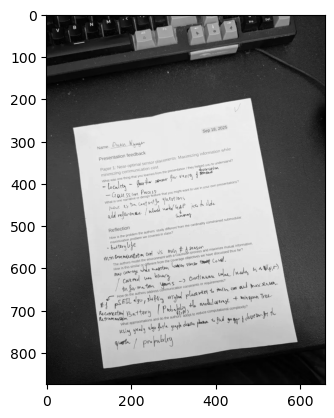

In [63]:
img_og = util.img_as_float32(io.imread('./HW01_2_test.webp'))
img = color.rgb2gray(img_og)
plt.imshow(img, cmap='gray')
plt.show()

EDGE DETECTION

In [64]:
edges = feature.canny(img, sigma=4, low_threshold=0.1, high_threshold=0.5)
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
# ax[0].imshow(img, cmap="gray")
# ax[0].set_title("input")
# ax[1].imshow(edges, cmap="gray")
# ax[1].set_title("canny edges")
# plt.show()

CORNER DETECTION

In [65]:
def harris_corner_detector(image, alpha=0.05, threshold=1e-3, window_size=3, sigma=1.0):
    # 1. Compute image derivatives
    Ix = filters.sobel_h(image) # compute horizontal derivative (x-direction)
    Iy = filters.sobel_v(image) # compute vertical derivative (y-direction)

    # 2. Compute products of derivatives
    Ixx = np.multiply(Ix, Ix) # Compute using hadamard product
    Iyy = np.multiply(Iy, Iy)# Compute using hadamard product
    Ixy = np.multiply(Ix, Iy)# Compute using hadamard product

    # 3. Gaussian filter to smooth the squared derivatives
    Sxx = filters.gaussian(Ixx, sigma=sigma) # Gaussian filter of Ixx
    Syy = filters.gaussian(Iyy, sigma=sigma) # Gaussian filter of Iyy
    Sxy = filters.gaussian(Ixy, sigma=sigma) # Gaussian filter of Ixy

    # 4. Compute cornerness 
    detM = np.multiply(Sxx, Syy) - (Sxy ** 2) # Must be a function of only Sxx, Syy, or Sxy
    traceM = Sxx + Syy # Must be a function of only Sxx, Syy, or Sxy
    C = detM - alpha * (traceM ** 2) # C Must be a function of only detM, traceM, and alpha

    # 5. Threshold C to remove weak corners
    C_thresh = (C > threshold * C.max()) * C

    # 6. Non-maximum suppression
    win_half_size = int(window_size // 2)
    corners = []
    for y in range(win_half_size, C.shape[0]-win_half_size):
        for x in range(win_half_size, C.shape[1]-win_half_size):
            if C_thresh[y, x] == np.max(C_thresh[y-win_half_size : y+win_half_size+1,  x-win_half_size : x+win_half_size+1]):
                if C_thresh[y, x] > 0:
                    corners.append((y, x))

    return corners, C

In [66]:
corners, C = harris_corner_detector(edges, alpha=0.05, threshold=0.1, window_size=3, sigma=3)
# fig, ax = plt.subplots()
# ax.imshow(img, cmap=plt.cm.gray)
# y, x = zip(*corners)
# ax.scatter(x, y, c='r', s=2)
# ax.set_title("Harris Corner Detection")

PLOT/OUTPUT

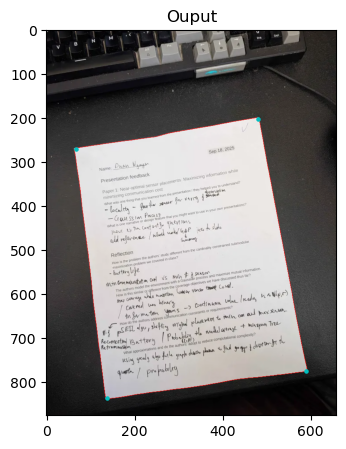

In [67]:
img_og[edges] = [1, 0, 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(img_og, cmap='gray' if img_og.ndim == 2 else None)
ax.set_title('Ouput')
y, x = zip(*corners)
ax.scatter(x, y, c='c', s=5)
plt.show()

TRANSFORMATION TEST

In [ ]:
# ROTATE

In [ ]:
#